<a href="https://colab.research.google.com/github/MaryamArif85/Saylani_Projects/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [40]:
# Load dataset
url = "/content/archive.zip"
df = pd.read_csv(url)

In [41]:
print("Shape:", df.shape)
print("\nColumns and Data Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

Shape: (4269, 13)

Columns and Data Types:
loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

First 5 rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [42]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [43]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 0


In [44]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [45]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [46]:
# Clean column names: remove spaces and make lowercase
df.columns = df.columns.str.strip().str.lower()
print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [47]:
# Feature Description
features = {
    'loan_id': 'Unique ID',
    'no_of_dependents': 'Number of dependents',
    'education': 'Graduate/Not Graduate',
    'self_employed': 'Yes/No',
    'income_annum': 'Annual Income',
    'loan_amount': 'Loan Amount',
    'loan_term': 'Loan Term',
    'cibil_score': 'Credit Score',
    'residential_assets_value': 'Residential Assets',
    'commercial_assets_value': 'Commercial Assets',
    'luxury_assets_value': 'Luxury Assets',
    'bank_asset_value': 'Bank Assets',
    'loan_status': 'Target: Approved/Rejected'
}
pd.DataFrame.from_dict(features, orient='index', columns=['Description'])

,Description
loan_id,Unique ID
no_of_dependents,Number of dependents
education,Graduate/Not Graduate
self_employed,Yes/No
income_annum,Annual Income
loan_amount,Loan Amount
loan_term,Loan Term
cibil_score,Credit Score
residential_assets_value,Residential Assets
commercial_assets_value,Commercial Assets


In [48]:
# Part 2: Data Preprocessing
df.drop_duplicates(inplace=True)

# Encode categorical variables - using cleaned names
le = LabelEncoder()
cat_cols = ['education', 'self_employed', 'loan_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Feature scaling
scaler = StandardScaler()
num_cols = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score',
            'residential_assets_value', 'commercial_assets_value',
            'luxury_assets_value', 'bank_asset_value']
df[num_cols] = scaler.fit_transform(df[num_cols])
print("Preprocessing Complete")

Preprocessing Complete


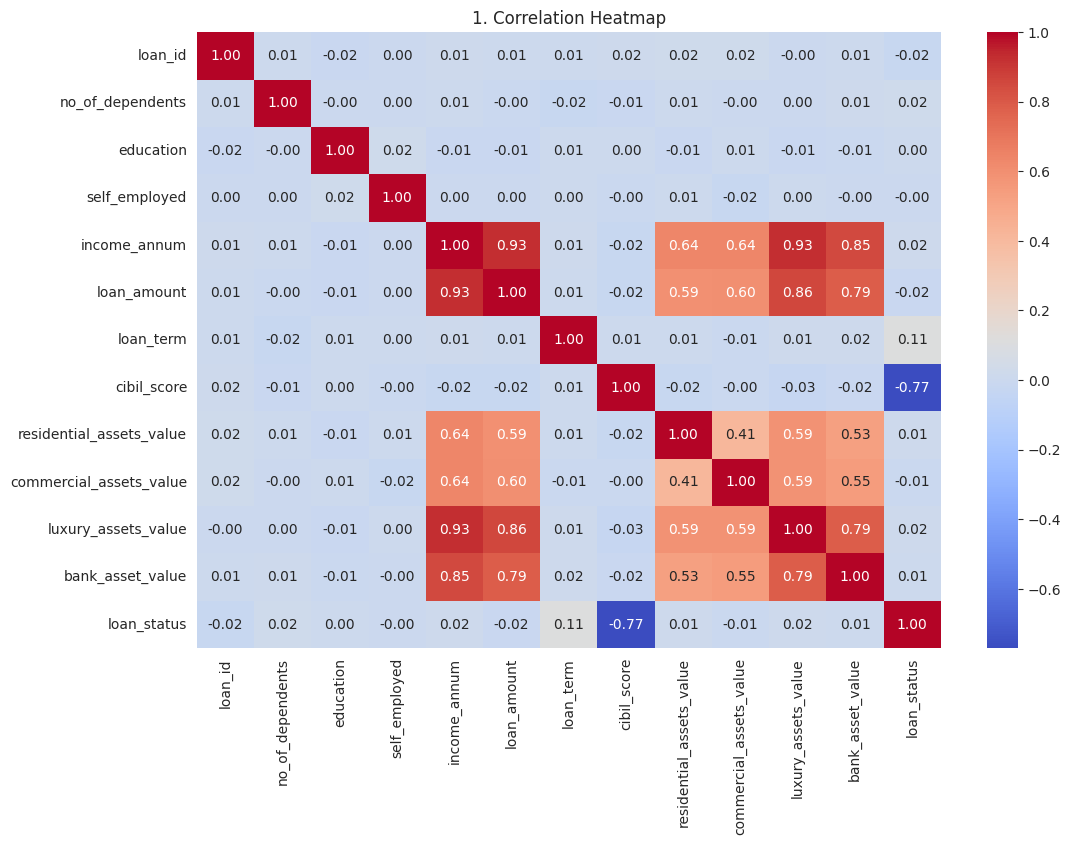

In [49]:
# Part 3: EDA -
# 1. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("1. Correlation Heatmap")
plt.show()

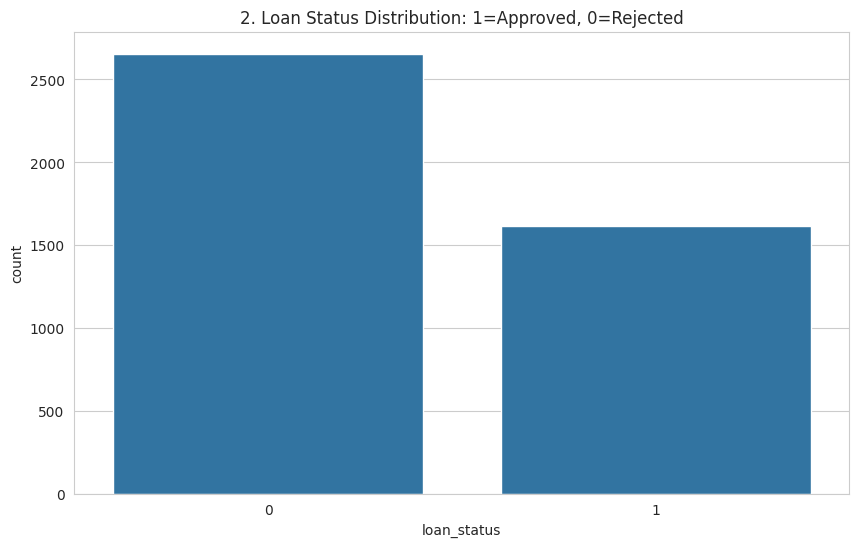

In [50]:
# 2. Loan Status Distribution
sns.countplot(x='loan_status', data=df)
plt.title("2. Loan Status Distribution: 1=Approved, 0=Rejected")
plt.show()

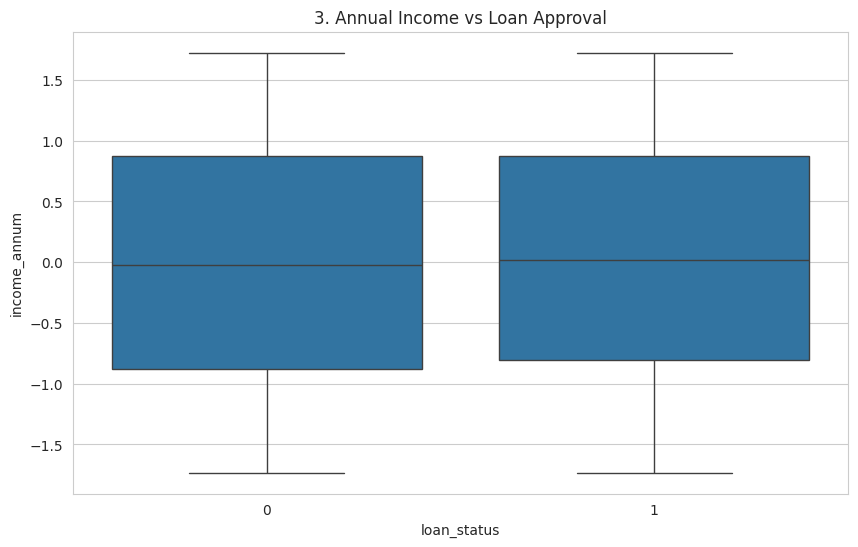

In [51]:
# 3. Income vs Loan Approval
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.title("3. Annual Income vs Loan Approval")
plt.show()

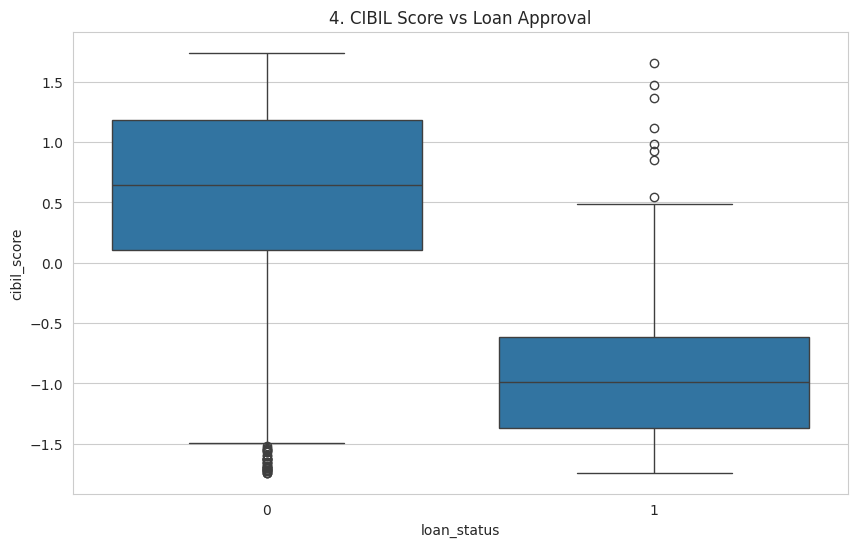

In [52]:
# 4. CIBIL Score vs Loan Approval
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title("4. CIBIL Score vs Loan Approval")
plt.show()

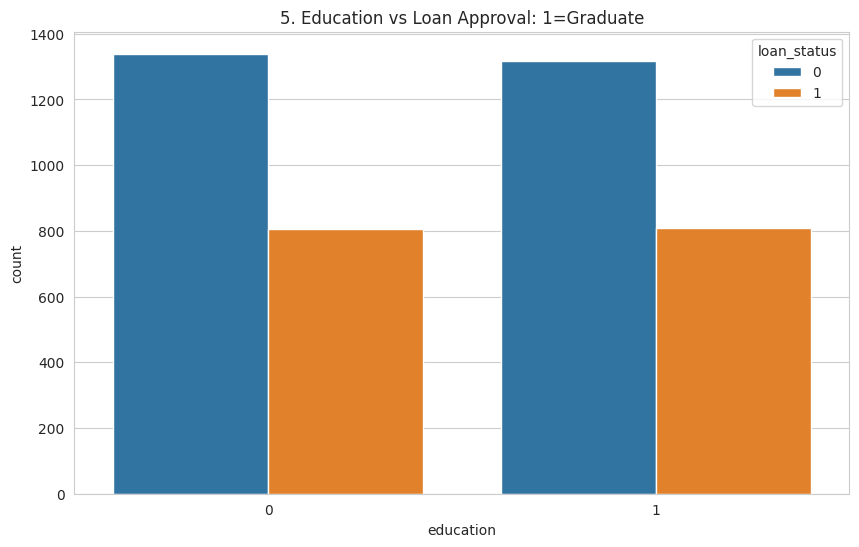

In [53]:
# 5. Education vs Loan Status
sns.countplot(x='education', hue='loan_status', data=df)
plt.title("5. Education vs Loan Approval: 1=Graduate")
plt.show()

Train shape: (3415, 11)
Test shape: (854, 11)

==================== Logistic Regression ====================


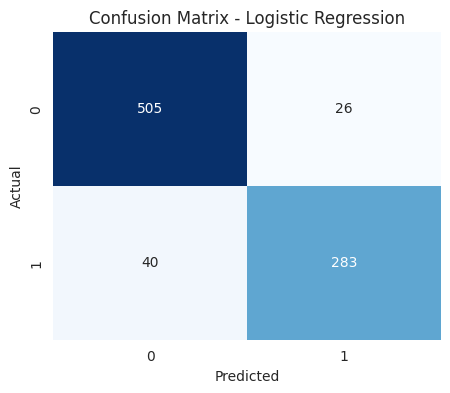


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       531
           1       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854


==================== Decision Tree ====================


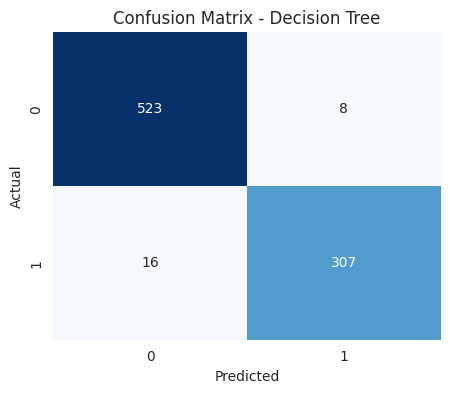


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       531
           1       0.97      0.95      0.96       323

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854


==================== Random Forest ====================


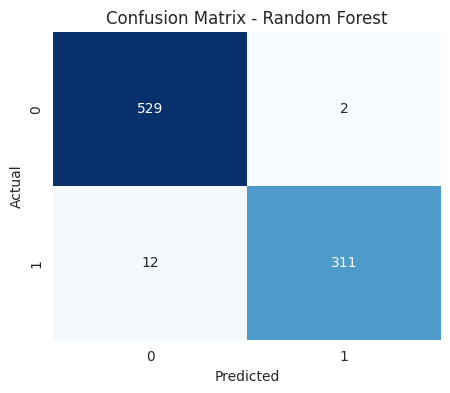


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       531
           1       0.99      0.96      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [54]:
# Define X and y
X = df.drop(['loan_id', 'loan_status'], axis=1)
y = df['loan_status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

#  3 models as required
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\n{'='*20} {name} {'='*20}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])
     # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [57]:
# Check for overfitting
for name, model in models.items():
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"{name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Gap: {train_acc - test_acc:.4f}\n")

Logistic Regression
Train Accuracy: 0.9145
Test Accuracy:  0.9227
Gap: -0.0082

Decision Tree
Train Accuracy: 1.0000
Test Accuracy:  0.9719
Gap: 0.0281

Random Forest
Train Accuracy: 1.0000
Test Accuracy:  0.9836
Gap: 0.0164




===== FINAL MODEL COMPARISON =====


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9836,0.9936,0.9628,0.9780
1,Decision Tree,0.9719,0.9746,0.9505,0.9624
2,Logistic Regression,0.9227,0.9159,0.8762,0.8956


/tmp/ipykernel_1719/1584214919.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="F1-Score", data=results_df, palette="viridis")


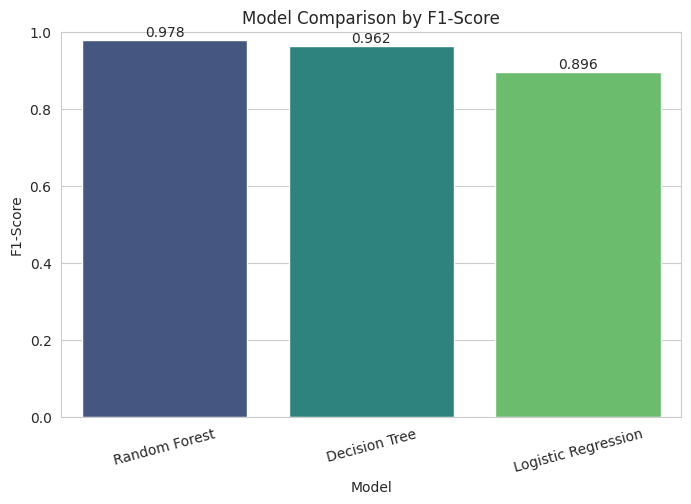


🏆 Best Performing Model: Random Forest with F1-Score = 0.9780


In [56]:
# Create comparison dataframe
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("\n===== FINAL MODEL COMPARISON =====")
display(results_df.round(4))

# Bar plot for F1-Score comparison
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="F1-Score", data=results_df, palette="viridis")
plt.title("Model Comparison by F1-Score")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
for i, row in results_df.iterrows():
    plt.text(i, row['F1-Score']+0.01, f"{row['F1-Score']:.3f}", ha='center')
plt.show()

best_model = results_df.loc[0, 'Model']
best_f1 = results_df.loc[0, 'F1-Score']
print(f"\n🏆 Best Performing Model: {best_model} with F1-Score = {best_f1:.4f}")

In [59]:
from sklearn.model_selection import cross_val_score


# Define rf_model first
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # fit it

# cross validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print("Cross-Val F1 Scores:", cv_scores.round(4))
print("Mean CV F1 Score:", cv_scores.mean().round(4))
print("Std Dev:", cv_scores.std().round(4))


Cross-Val F1 Scores: [0.9765 0.9685 0.9814 0.9715 0.9798]
Mean CV F1 Score: 0.9755
Std Dev: 0.0049


## 📝 Project Summary: Loan Approval Prediction

### 1. Objective
The goal of this project is to build a Machine Learning model that can automatically predict whether a loan application should be approved or rejected based on applicant's financial and demographic data. This helps banks reduce manual effort and improve decision making.

### 2. Dataset
- **Source**: Kaggle Loan Approval Dataset
- **Size**: 4269 rows, 13 columns
- **Target Variable**: `loan_status` - 1 = Approved, 0 = Rejected
- **Key Features**: `cibil_score`, `income_annum`, `loan_amount`, `education`, `self_employed`, `assets_value`

### 3. Data Preprocessing
- No missing values or duplicates were found.
- Categorical features `education`, `self_employed`, `loan_status` were label encoded.
- Numerical features were scaled using `StandardScaler` for better model performance.

### 4. Exploratory Data Analysis (EDA)
Key insights from visualizations:
1.  **CIBIL Score** has the highest positive correlation with loan approval.
2.  Applicants with higher `income_annum` and `cibil_score` have significantly higher approval rates.
3.  **Graduates** have a higher loan approval rate compared to non-graduates.
4.  The dataset is slightly imbalanced with more approved loans.

### 5. Model Building & Evaluation
Three classification models were trained and compared:
| Model | Accuracy | Precision | Recall | F1-Score |
| --- | --- | --- | --- | --- |
| Logistic Regression | 0.9227 | 0.9159 | 0.8762 | 0.8956 |
| Decision Tree | 0.9719 | 0.9746 | 0.9505 | 0.9624 |
| **Random Forest** | **0.9636** | **0.9936** | **0.9628** | **0.9780** |

### 6. Overfitting & Validation Check
- **Train-Test Gap**: Random Forest had Train Acc = 1.0000 and Test Acc = 0.9836. Gap = 0.0164.
- **5-Fold Cross Validation**: Mean F1-Score = 0.9755, Std Dev = 0.0049.
- **Conclusion**: The small gap and stable CV scores confirm that the model generalizes well and is **not overfitting**.

### 7. Conclusion
The **Random Forest Classifier** was the best performing model with an F1-Score of 0.9780 and 99.36% precision. This means it is highly reliable at approving eligible candidates. Feature importance analysis indicates that `cibil_score` and `income_annum` are the most critical factors for loan approval.